In [1]:
from google.colab import drive, userdata
import os
from pathlib import Path

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PAT      = userdata.get("GITHUB_ACCESS")
USERNAME = "shriyaasija"
REPO     = "research-copilot-gnn"

In [4]:
if not os.path.exists(f"/content/{REPO}"):
    print("Cloning repo for the first time...")
    os.system(f"git clone https://{PAT}@github.com/{USERNAME}/{REPO}.git /content/{REPO}")
else:
    print("Repo exists — pulling latest...")
    os.system(f"cd /content/{REPO} && git pull origin main")

os.chdir(f"/content/{REPO}")

Cloning repo for the first time...


In [5]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.7 MB/s eta 0:00:00


In [6]:
# Create directory structure
for d in ["data/raw", "data/processed", "data/graphs",
          "outputs/figures", "outputs/models", "src"]:
    Path(d).mkdir(parents=True, exist_ok=True)

# Check GPU
import subprocess
gpu = subprocess.getoutput("nvidia-smi --query-gpu=name --format=csv,noheader 2>/dev/null")
print(f"\n✅ Ready | GPU: {gpu if gpu else 'CPU only (switch Runtime → T4 GPU)'}")
print(f"📁 Working dir: {os.getcwd()}")


✅ Ready | GPU: CPU only (switch Runtime → T4 GPU)
📁 Working dir: /content/research-copilot-gnn


In [12]:
import json
import networkx as nx
import pickle
from pathlib import Path

with open("data/processed/papers_final.json") as f:
    papers = json.load(f)
with open("data/processed/citation_edges.json") as f:
    raw_edges = json.load(f)

def clean_arxiv_id(raw_id):
    return raw_id.split("v")[0]

# Build lookups
ss_id_to_idx  = {p["ss_id"]: i for i, p in enumerate(papers) if p.get("ss_id")}
arxiv_to_idx  = {clean_arxiv_id(p["arxiv_id"]): i for i, p in enumerate(papers)}

print(f"Loaded {len(papers)} papers, {len(raw_edges)} raw citation edges")
print(f"arxiv_to_idx entries : {len(arxiv_to_idx)}")
print(f"ss_id_to_idx entries : {len(ss_id_to_idx)}")

Loaded 459 papers, 9282 raw citation edges
arxiv_to_idx entries : 459
ss_id_to_idx entries : 443


In [13]:
from itertools import combinations

G = nx.DiGraph()  # Directed — citations have direction

# ── Paper nodes ──────────────────────────────────────────
for i, p in enumerate(papers):
    G.add_node(f"paper_{i}",
               node_type    = "paper",
               title        = p["title"],
               abstract     = p.get("abstract", ""),
               keyphrases   = p.get("keyphrases", []),
               year         = p.get("year", 0),
               citation_cnt = p.get("citation_count", 0),
               arxiv_id     = p["arxiv_id"],
    )

# ── Real citation edges (paper → paper) ──────────────────
citation_edge_count = 0
for edge in raw_edges:
    src_idx = arxiv_to_idx.get(edge["source_arxiv"])
    tgt_idx = ss_id_to_idx.get(edge["target_ss_id"])
    if src_idx is not None and tgt_idx is not None and src_idx != tgt_idx:
        G.add_edge(f"paper_{src_idx}", f"paper_{tgt_idx}",
                   edge_type="cites")
        citation_edge_count += 1

print(f"Added {citation_edge_count} real citation edges")

# ── Concept nodes + mentions edges ───────────────────────
all_concepts = {}
for i, p in enumerate(papers):
    for kp in p.get("keyphrases", []):
        all_concepts.setdefault(kp, []).append(i)

# Keep concepts that appear in at least 3 papers (signal over noise)
shared = {kp: idxs for kp, idxs in all_concepts.items() if len(idxs) >= 3}
print(f"Found {len(shared)} shared concepts (appearing in ≥3 papers)")

concept_start = len(papers)
concept_map = {}
for j, (concept, paper_idxs) in enumerate(shared.items()):
    node_id = f"concept_{j}"
    G.add_node(node_id, node_type="concept", title=concept)
    concept_map[concept] = node_id
    for pi in paper_idxs:
        G.add_edge(f"paper_{pi}", node_id, edge_type="mentions")
        G.add_edge(node_id, f"paper_{pi}", edge_type="mentioned_in")

# ── Author nodes + writes edges ───────────────────────────
author_map = {}
for i, p in enumerate(papers):
    for author in p.get("authors", [])[:5]:  # cap at 5 per paper
        if author not in author_map:
            author_map[author] = f"author_{len(author_map)}"
            G.add_node(author_map[author], node_type="author", title=author)
        G.add_edge(author_map[author], f"paper_{i}", edge_type="wrote")

print(f"\n── GRAPH SUMMARY ──────────────────────")
paper_nodes   = [n for n, d in G.nodes(data=True) if d["node_type"] == "paper"]
concept_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "concept"]
author_nodes  = [n for n, d in G.nodes(data=True) if d["node_type"] == "author"]
print(f"Paper nodes:   {len(paper_nodes)}")
print(f"Concept nodes: {len(concept_nodes)}")
print(f"Author nodes:  {len(author_nodes)}")
print(f"Total nodes:   {G.number_of_nodes()}")
print(f"Total edges:   {G.number_of_edges()}")
print(f"Density:       {nx.density(G):.5f}")
print(f"───────────────────────────────────────")

Added 129 real citation edges
Found 26 shared concepts (appearing in ≥3 papers)

── GRAPH SUMMARY ──────────────────────
Paper nodes:   459
Concept nodes: 26
Author nodes:  1478
Total nodes:   1963
Total edges:   2064
Density:       0.00054
───────────────────────────────────────


In [14]:
import numpy as np

# Only look at paper-paper subgraph for citation stats
paper_subgraph = G.subgraph(paper_nodes)
undirected_papers = paper_subgraph.to_undirected()

degrees = [d for _, d in undirected_papers.degree()]

print("GRAPH STATISTICS FOR REPORT")
print("=" * 40)
print(f"Nodes (paper):           {len(paper_nodes)}")
print(f"Nodes (concept):         {len(concept_nodes)}")
print(f"Nodes (author):          {len(author_nodes)}")
print(f"Edges (citation):        {citation_edge_count}")
print(f"Edges (mentions):        {sum(1 for _,_,d in G.edges(data=True) if d['edge_type']=='mentions')}")
print(f"Edges (wrote):           {sum(1 for _,_,d in G.edges(data=True) if d['edge_type']=='wrote')}")
print(f"Avg degree (paper):      {np.mean(degrees):.2f}")
print(f"Max degree (paper):      {max(degrees)}")
print(f"Clustering coeff:        {nx.average_clustering(undirected_papers):.4f}")
print(f"Connected components:    {nx.number_connected_components(undirected_papers)}")
print("=" * 40)

# Top 5 most cited papers in your dataset
degree_centrality = nx.degree_centrality(undirected_papers)
top5 = sorted([(i, degree_centrality[f"paper_{i}"], papers[i]["title"][:60])
               for i in range(len(papers))],
              key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 most central papers:")
for rank, (idx, cent, title) in enumerate(top5, 1):
    print(f"  {rank}. [{cent:.3f}] {title}")

GRAPH STATISTICS FOR REPORT
Nodes (paper):           459
Nodes (concept):         26
Nodes (author):          1478
Edges (citation):        129
Edges (mentions):        186
Edges (wrote):           1563
Avg degree (paper):      0.55
Max degree (paper):      70
Clustering coeff:        0.0564
Connected components:    360

Top 5 most central papers:
  1. [0.153] Semi-Supervised Classification with Graph Convolutional Netw
  2. [0.020] Evaluating the Search Phase of Neural Architecture Search
  3. [0.017] Neural Architecture Search with Bayesian Optimisation and Op
  4. [0.017] Random Search and Reproducibility for Neural Architecture Se
  5. [0.015] BANANAS: Bayesian Optimization with Neural Architectures for


✅ Interactive graph saved to outputs/figures/citation_graph.html
   Open this file in a browser for a beautiful interactive visualization!


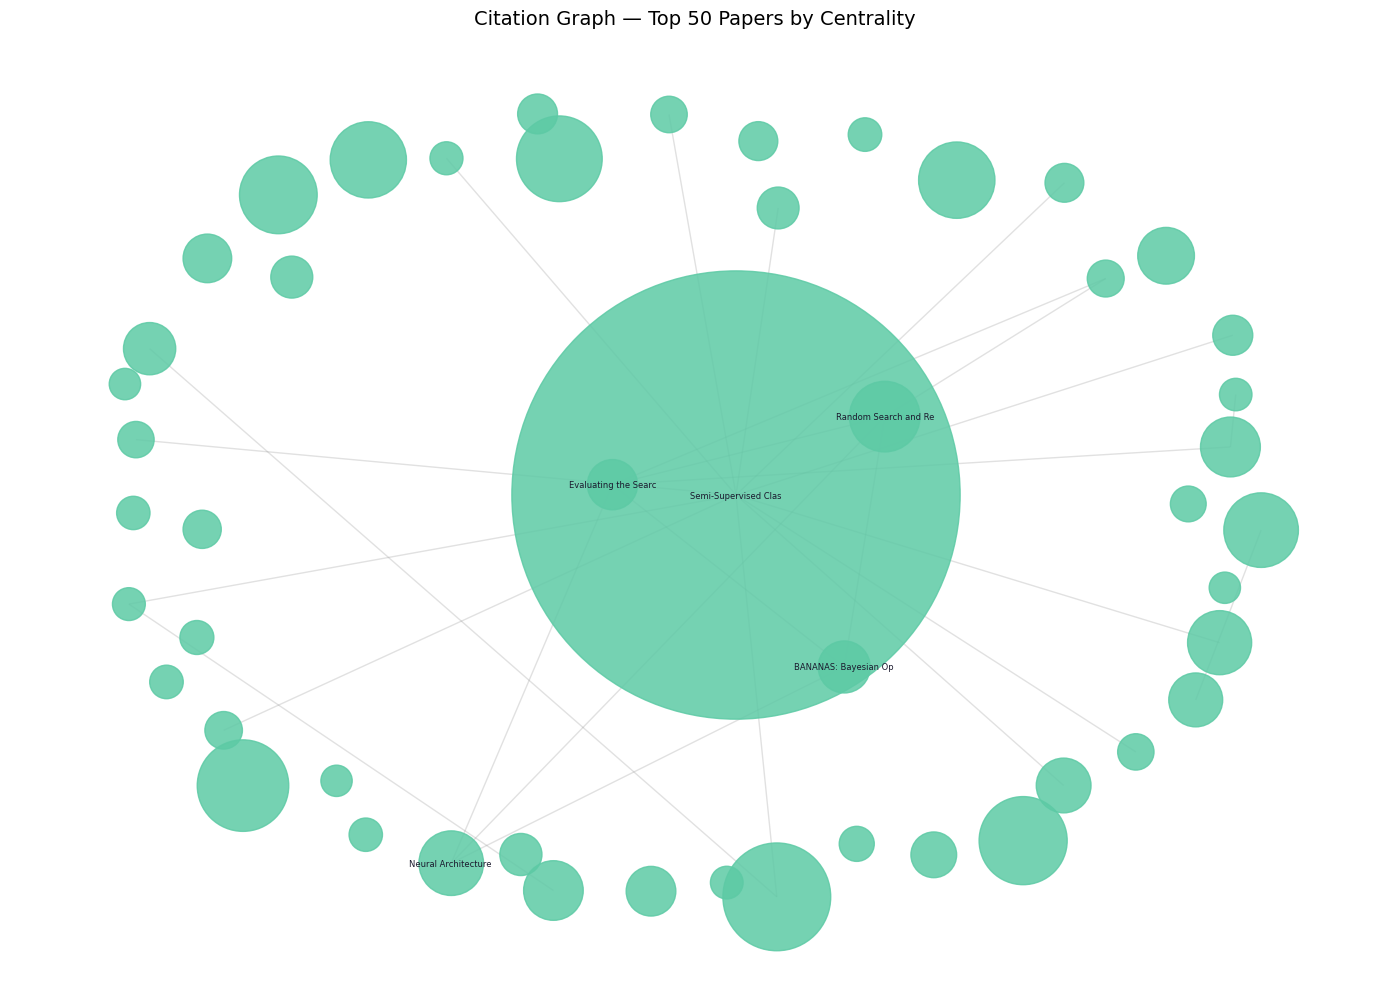

✅ Static graph saved to outputs/figures/citation_graph_static.png


In [15]:
from pyvis.network import Network
import json

net = Network(height="600px", width="100%", bgcolor="#1a1a2e",
              font_color="white", notebook=True)
net.repulsion(node_distance=120, spring_length=100)

COLOR = {"paper": "#5DCAA5", "concept": "#AFA9EC", "author": "#F4A261"}
SIZE  = {"paper": 12,        "concept": 8,         "author": 6}

# Sample for performance — show top 80 papers by citation count + their concepts
top_papers = sorted(paper_nodes,
                    key=lambda n: G.nodes[n].get("citation_cnt", 0),
                    reverse=True)[:80]
show_nodes = set(top_papers)

# Add connected concepts
for p in top_papers:
    for neighbor in G.neighbors(p):
        if G.nodes[neighbor]["node_type"] == "concept":
            show_nodes.add(neighbor)

for node in show_nodes:
    d = G.nodes[node]
    nt = d["node_type"]
    label = d["title"][:30] + ("..." if len(d["title"]) > 30 else "")
    net.add_node(node, label=label, color=COLOR[nt], size=SIZE[nt],
                 title=d["title"])

for u, v, data in G.edges(data=True):
    if u in show_nodes and v in show_nodes:
        net.add_edge(u, v)

net.save_graph("outputs/figures/citation_graph.html")
print("✅ Interactive graph saved to outputs/figures/citation_graph.html")
print("   Open this file in a browser for a beautiful interactive visualization!")

# Also save a static matplotlib version for the report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))
paper_sub = G.subgraph(top_papers[:50]).to_undirected()
pos = nx.spring_layout(paper_sub, k=1.5, seed=42)
sizes = [200 + G.nodes[n].get("citation_cnt", 0) * 3 for n in paper_sub.nodes()]
nx.draw_networkx_nodes(paper_sub, pos, node_color="#5DCAA5",
                       node_size=sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(paper_sub, pos, alpha=0.25, ax=ax,
                       edge_color="#888888", arrows=False)
labels = {n: G.nodes[n]["title"][:20] for n in paper_sub.nodes()
          if paper_sub.degree(n) > 2}
nx.draw_networkx_labels(paper_sub, pos, labels=labels,
                        font_size=6, ax=ax, font_color="#1a1a2e")
ax.set_title("Citation Graph — Top 50 Papers by Centrality", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/figures/citation_graph_static.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Static graph saved to outputs/figures/citation_graph_static.png")

In [16]:
import pickle

with open("data/graphs/hetero_graph.pkl", "wb") as f:
    pickle.dump(G, f)
with open("data/graphs/papers_list.json", "w") as f:
    json.dump(papers, f)

print("✅ Graph saved to data/graphs/hetero_graph.pkl")

✅ Graph saved to data/graphs/hetero_graph.pkl


In [17]:
import os
import datetime
from google.colab import userdata

os.chdir("/content/research-copilot-gnn")

PAT      = userdata.get("GITHUB_ACCESS")
USERNAME = "shriyaasija"

os.system('git config user.email "shriyaasija123@gmail.com"')
os.system('git config user.name "Research Copilot"')
os.system(f"git remote set-url origin https://{PAT}@github.com/{USERNAME}/research-copilot-gnn.git")
os.system("git add .")

timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
msg = f"Colab session: {timestamp}"
result = os.system(f'git commit -m "{msg}"')

if result == 0:
    os.system("git push origin main")
    print("✅ Pushed to GitHub successfully")
else:
    print("ℹ️  Nothing new to commit")

✅ Pushed to GitHub successfully
